# 02_theme_analysis

This notebook identifies recurring themes in CFPB credit card complaint narratives using a baseline interpretable NLP workflow.

Main tasks:
- Load the text-prepped complaint dataset
- Vectorize complaint  narratives with TF-IDF
- Fit an NMF model to identify recurring themes
- Inspect top terms and example narratives for each theme
- Assign each complaint a dominant theme
- Measure theme prevalence by quarter
- Save theme outputs for later visuals and interpretation

### Imports

In [3]:
# Standard library
from pathlib import Path

# Third-party libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

### Paths

In [4]:
# Assume the notebook is being run from the notebooks/ folder.
# PROJECT_ROOT points to the repo root so file paths stay portable.
PROJECT_ROOT = Path.cwd().parent

# Processed data directory used when transferring work between notebooks.
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Output folder for tables and figures created in this notebook.
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

PROJECT_ROOT, DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES


(WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/data/processed'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/outputs/tables'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/outputs/figures'))

### Load text-prepped data

In [5]:
# Load the text-prepped complaint dataset created in 01_text_prep.ipynb
input_csv = DATA_PROCESSED / "cfpb_credit_card_complaints_text_prep.csv"

complaints = pd.read_csv(
    input_csv,
    parse_dates=["date_received", "quarter_start"],
)

complaints.shape

(76879, 17)

### Basic checks

In [6]:
# Confirm the dataset shape and the key text fields used for theme analysis.
print("Rows:", len(complaints))
print("Unique complaint IDs:", complaints["complaint_id"].nunique())
print("Blank cleaned narratives:", (complaints["narrative_text_clean"] == "").sum())
print("Quarter coverage:", complaints["quarter_label"].nunique())

Rows: 76879
Unique complaint IDs: 76879
Blank cleaned narratives: 0
Quarter coverage: 8


### Minimum word filter

In [7]:
# Remove very short narratives that are unlikely to contribute meaningful theme information.
# Keep the threshold modest for the first pass.
MIN_WORDS = 20

theme_input = complaints.loc[
    complaints["narrative_word_count"] >= MIN_WORDS
].copy()

print("Rows kept for theme modeling:", len(theme_input))
print("Rows removed by minimum word threshold:", len(complaints) - len(theme_input))

Rows kept for theme modeling: 74959
Rows removed by minimum word threshold: 1920


### Check for duplicate narratives

In [8]:
# Check for exact duplicate cleaned narratives.
duplicate_text = (
    theme_input.groupby("narrative_text_clean", dropna=False)
    .agg(
        complaint_count=("complaint_id", "size"),
        example_complaint_id=("complaint_id", "first"),
        example_issue=("issue", "first"),
        example_sub_issue=("sub_issue", "first"),
    )
    .reset_index()
    .sort_values("complaint_count", ascending=False)
)

duplicate_text.head(20)

,narrative_text_clean,complaint_count,example_complaint_id,example_issue,example_sub_issue
47327,my information was heisted and this accounts a...,473,9691993,Getting a credit card,Card opened without my consent or knowledge
45894,my accounts was never late! i have had excepti...,372,15254020,Problem with a company's investigation into an...,Was not notified of investigation status or re...
15076,i affirm that the inclusion of incorrectly rep...,181,8554272,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...
18096,i am requesting your help to investigate such ...,152,10647453,Incorrect information on your report,Account status incorrect
58975,see the attached documents. i want the bureau ...,136,8161746,Problem with a company's investigation into an...,Was not notified of investigation status or re...
31467,i need your assistance in reviewing accounts f...,95,12053815,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...
41315,i've consistently upheld timely payments on th...,77,8338565,Problem with a company's investigation into an...,Was not notified of investigation status or re...
21390,i assert that adding inaccurate late payment r...,74,8595269,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...
41303,i've consistently maintained timely payments o...,73,8251807,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...
28358,i have consistently made punctual payments on ...,62,8542044,Incorrect information on your report,Account status incorrect


### Deduplicate exact clean narratives

In [9]:
# Remove exact duplicate cleaned narratives before theme discovery.
# This reduces the influence of repeated complaints.
theme_input_dedup = (
    theme_input
    .sort_values(["narrative_text_clean", "complaint_id"])
    .drop_duplicates(subset="narrative_text_clean")
    .copy()
)

print("Original theme input rows:", len(theme_input))
print("Deduplicated theme input rows:", len(theme_input_dedup))
print("Rows removed as exact duplicate cleaned narratives:", len(theme_input) - len(theme_input_dedup))

Original theme input rows: 74959
Deduplicated theme input rows: 68906
Rows removed as exact duplicate cleaned narratives: 6053


### Model input

In [10]:
# Use the deduplicated dataset for theme discovery.
model_input = theme_input_dedup.copy()

print("Modeling rows:", len(model_input))

Modeling rows: 68906


### TF-IDF vectorizer

In [11]:
# Create the TF-IDF representation used by the NMF model.
# Use unigrams and bigrams to capture short complaint phrases.
vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=10,
    ngram_range=(1,2),
    stop_words="english",
    max_features=5000,
)

tfidf_matrix = vectorizer.fit_transform(model_input["narrative_text_clean"])

tfidf_matrix.shape

(68906, 5000)

### NMF model fit

In [12]:
# Fit a baseline NMF model.
# Start with 8 themes for the first pass. This can be adjusted after inspection.
N_TOPICS = 8

nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=42,
    init="nndsvda",
    max_iter=400,
)

topic_weights = nmf_model.fit_transform(tfidf_matrix)

topic_weights.shape

(68906, 8)

### Inspect top terms per theme

In [13]:
# Build a theme term table to inspect the most important words and phrases associated with each theme.
feature_names = vectorizer.get_feature_names_out()

def get_top_terms(model, features, top_n=12):
    """Return the top weighted terms for each NMF component."""
    rows = []

    for topic_idx, component in enumerate(model.components_):
        top_term_idx = component.argsort()[::-1][:top_n]
        top_terms = [features[i] for i in top_term_idx]

        rows.append(
            {
                "theme_id": topic_idx,
                "top_terms": ", ".join(top_terms),
            }
        )

    return pd.DataFrame(rows)

theme_terms = get_top_terms(nmf_model, feature_names, top_n=12)
theme_terms

,theme_id,top_terms
0,0,"card, credit, credit card, account, called, to..."
1,1,"credit, report, reporting, account, informatio..."
2,2,"payment, balance, late, fee, account, payments..."
3,3,"dispute, chase, merchant, charge, refund, char..."
4,4,"american, american express, express, amex, poi..."
5,5,"wells, fargo, wells fargo, fargo credit, fargo..."
6,6,"usc, 15 usc, late payment, 15, late, payment r..."
7,7,"bank, bank america, america, synchrony, synchr..."


### Assign dominant theme

In [14]:
# Assign each complaint to the theme with the highest NMF weight.
model_input["theme_id"] = topic_weights.argmax(axis=1)
model_input["theme_strength"] = topic_weights.max(axis=1)

model_input[
    [
        "complaint_id",
        "quarter_label",
        "issue",
        "sub_issue",
        "theme_id",
        "theme_strength",
    ]
].head()

,complaint_id,quarter_label,issue,sub_issue,theme_id,theme_strength
70284,16985487,2025 Q4,Trouble using your card,Credit card company won't increase or decrease...,0,0.028645
56111,14546557,2025 Q3,Incorrect information on your report,Account information incorrect,1,0.031015
46033,12870425,2025 Q2,Fees or interest,Problem with fees,2,0.045663
37283,11580477,2025 Q1,Fees or interest,Problem with fees,4,0.053633
37511,11670768,2025 Q1,Getting a credit card,Card opened without my consent or knowledge,1,0.025629


### Theme sizes

In [15]:
# Summarize how many complaints fall into each dominant theme.
theme_counts = (
    model_input["theme_id"]
    .value_counts()
    .sort_index()
    .rename_axis("theme_id")
    .reset_index(name="complaint_count")
)

theme_counts["theme_share"] = theme_counts["complaint_count"] / len(model_input)

theme_counts.merge(theme_terms, on="theme_id", how="left")

,theme_id,complaint_count,theme_share,top_terms
0,0,16802,0.243839,"card, credit, credit card, account, called, to..."
1,1,9544,0.138508,"credit, report, reporting, account, informatio..."
2,2,16270,0.236119,"payment, balance, late, fee, account, payments..."
3,3,14427,0.209372,"dispute, chase, merchant, charge, refund, char..."
4,4,3284,0.047659,"american, american express, express, amex, poi..."
5,5,1933,0.028053,"wells, fargo, wells fargo, fargo credit, fargo..."
6,6,1974,0.028648,"usc, 15 usc, late payment, 15, late, payment r..."
7,7,4672,0.067803,"bank, bank america, america, synchrony, synchr..."


### Inspect sample narratives by theme

In [16]:
# Review a few strong example narratives for each theme.
# This helps turn model output into readable labels.
import textwrap

for theme_id in sorted(model_input["theme_id"].unique()):
    print(f"\n{'=' * 80}")
    print(f"Theme {theme_id}")
    print(theme_terms.loc[theme_terms["theme_id"] == theme_id, "top_terms"].iloc[0])
          
    sample_rows = model_input.loc[model_input["theme_id"] == theme_id].sort_values(
        "theme_strength", ascending=False
    ).head(3)

    for _, row in sample_rows.iterrows():
        print("\n--- Example narrative ---")
        print(f"Complaint ID: {row['complaint_id']}")
        print(f"Issue: {row['issue']}")
        print(f"Sub-issue: {row['sub_issue']}")
        print(textwrap.fill(row["consumer_complaint_narrative"][:1500], width=200))


Theme 0
card, credit, credit card, account, called, told, capital, said, number, company, did, closed

--- Example narrative ---
Complaint ID: 12132362
Issue: Getting a credit card
Sub-issue: Card opened without my consent or knowledge
On XX/XX/year>, me and my husband went to a XXXX 's fragrance department in XXXX XXXX XXXX at XXXX XXXX. A lady named XXXX approached us to help with finding a fragrance. Once ready to purchase she
said if I applied for a credit card I could received discount. I told her I did not want to apply for a credit card as I already had one as an authorized user through my husband 's account. She
proceeded to verify the account online since I did not have the physical card with me. She told me that my account was inactive and that I would need to apply for a new once to become activated. I
told her I am the only one who uses the card I knew it was active and not expired as I use it all the time. She said only my husband 's account was active but in order to get

### Manual theme label map

In [17]:
# Replace the placeholder labels below after reviewing the theme terms and sample narratives above.
theme_label_map = {
    0: "Card opening, conversion, and unauthorized account changes",
    1: "Credit reporting accuracy and FCRA disputes",
    2: "Late fee and payment posting disputes",
    3: "Merchant charge disputes and refund resolution",
    4: "American Express account servicing and dispute problems",
    5: "Wells Fargo account servicing and claim handling issues",
    6: "Late payment remark correction disputes",
    7: "Bank of America fraud, refund, and account servicing issues",
}

model_input["theme_label"] = model_input["theme_id"].map(theme_label_map)

model_input[["theme_id", "theme_label"]].drop_duplicates().sort_values("theme_id")

,theme_id,theme_label
70284,0,"Card opening, conversion, and unauthorized acc..."
56111,1,Credit reporting accuracy and FCRA disputes
46033,2,Late fee and payment posting disputes
57950,3,Merchant charge disputes and refund resolution
37283,4,American Express account servicing and dispute...
67484,5,Wells Fargo account servicing and claim handli...
68673,6,Late payment remark correction disputes
33989,7,"Bank of America fraud, refund, and account ser..."


### Create theme summary table

In [18]:
# Summarize the labeled themes after manual review.
theme_summary = (
    model_input.groupby(["theme_id", "theme_label"])
    .size()
    .reset_index(name="complaint_count")
    .sort_values("complaint_count", ascending=False)
)

theme_summary["theme_share"] = theme_summary["complaint_count"] / len(model_input)

theme_summary = theme_summary.merge(
    theme_terms,
    on="theme_id",
    how="left",
)

theme_summary

,theme_id,theme_label,complaint_count,theme_share,top_terms
0,0,"Card opening, conversion, and unauthorized acc...",16802,0.243839,"card, credit, credit card, account, called, to..."
1,2,Late fee and payment posting disputes,16270,0.236119,"payment, balance, late, fee, account, payments..."
2,3,Merchant charge disputes and refund resolution,14427,0.209372,"dispute, chase, merchant, charge, refund, char..."
3,1,Credit reporting accuracy and FCRA disputes,9544,0.138508,"credit, report, reporting, account, informatio..."
4,7,"Bank of America fraud, refund, and account ser...",4672,0.067803,"bank, bank america, america, synchrony, synchr..."
5,4,American Express account servicing and dispute...,3284,0.047659,"american, american express, express, amex, poi..."
6,6,Late payment remark correction disputes,1974,0.028648,"usc, 15 usc, late payment, 15, late, payment r..."
7,5,Wells Fargo account servicing and claim handli...,1933,0.028053,"wells, fargo, wells fargo, fargo credit, fargo..."


### Create broader reporting groups

In [19]:
# Create broader reporting groups for interpretation and charting.
# Keep the original theme_label column, but add a cleaner final grouping layer.
final_theme_group_map = {
    "Card opening, conversion, and unauthorized account changes":
        "Card opening and account change issues",

    "Late fee and payment posting disputes":
        "Late fee and payment posting disputes",

    "Merchant charge disputes and refund resolution":
        "Merchant charge disputes and refund resolution",

    "Credit reporting accuracy and FCRA disputes":
        "Credit reporting accuracy and FCRA disputes",

    "Late payment remark correction disputes":
        "Credit reporting and payment remark disputes",

    "American Express account servicing and dispute problems":
        "Issuer-specific servicing and dispute issues",

    "Wells Fargo account servicing and claim handling issues":
        "Issuer-specific servicing and dispute issues",

    "Bank of America fraud, refund, and account servicing issues":
        "Issuer-specific servicing and dispute issues",
}

model_input["final_theme_group"] = model_input["theme_label"].map(final_theme_group_map)

model_input[
    ["theme_id", "theme_label", "final_theme_group"]
].drop_duplicates().sort_values(["final_theme_group", "theme_id"])

,theme_id,theme_label,final_theme_group
70284,0,"Card opening, conversion, and unauthorized acc...",Card opening and account change issues
56111,1,Credit reporting accuracy and FCRA disputes,Credit reporting accuracy and FCRA disputes
68673,6,Late payment remark correction disputes,Credit reporting and payment remark disputes
37283,4,American Express account servicing and dispute...,Issuer-specific servicing and dispute issues
67484,5,Wells Fargo account servicing and claim handli...,Issuer-specific servicing and dispute issues
33989,7,"Bank of America fraud, refund, and account ser...",Issuer-specific servicing and dispute issues
46033,2,Late fee and payment posting disputes,Late fee and payment posting disputes
57950,3,Merchant charge disputes and refund resolution,Merchant charge disputes and refund resolution


### Summarize broader reporting groups

In [20]:
# Summarize the broader reporting groups after collapsing weaker or related themes.
final_theme_summary = (
    model_input.groupby("final_theme_group")
    .size()
    .reset_index(name="complaint_count")
    .sort_values("complaint_count", ascending=False)
)

final_theme_summary["theme_share"] = (
    final_theme_summary["complaint_count"] / len(model_input)
)

final_theme_summary

,final_theme_group,complaint_count,theme_share
0,Card opening and account change issues,16802,0.243839
4,Late fee and payment posting disputes,16270,0.236119
5,Merchant charge disputes and refund resolution,14427,0.209372
3,Issuer-specific servicing and dispute issues,9889,0.143514
1,Credit reporting accuracy and FCRA disputes,9544,0.138508
2,Credit reporting and payment remark disputes,1974,0.028648


### Plot broader reporting groups

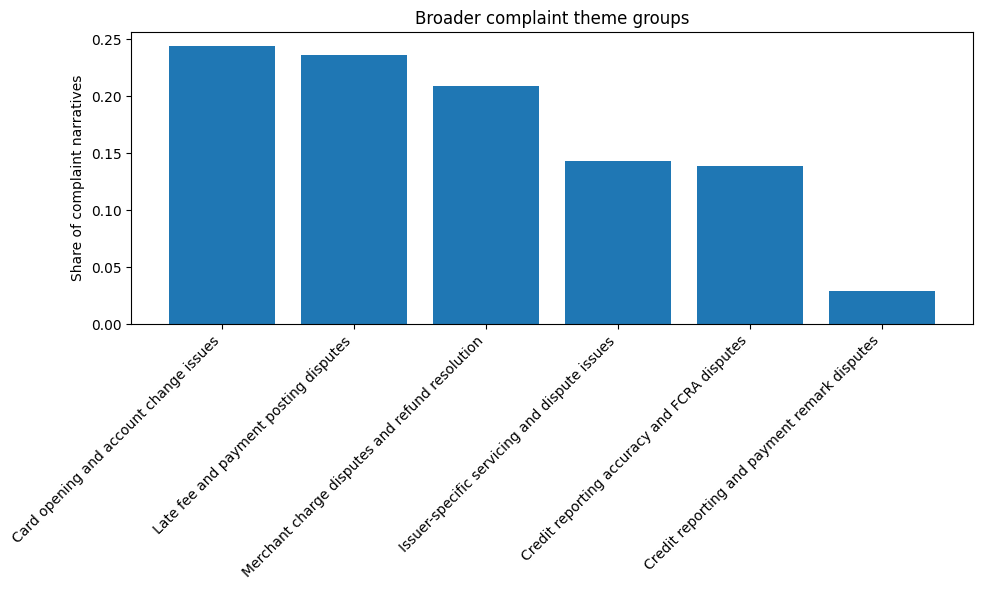

In [21]:
# Plot the broader reporting groups by share of complaint narratives.
plot_data = final_theme_summary.sort_values("theme_share", ascending=False).copy()

plt.figure(figsize=(10,6))
plt.bar(plot_data["final_theme_group"], plot_data["theme_share"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share of complaint narratives")
plt.title("Broader complaint theme groups")
plt.tight_layout()
plt.show()

### Summarize quarterly trends for broader reporting groups

In [22]:
# Summaraize complaint counts and shares by quarter for the broader reporting groups.
quarterly_group_counts = (
    model_input.groupby(["quarter_start", "quarter_label", "final_theme_group"])
    .size()
    .reset_index(name="complaint_count")
)

quarterly_totals = (
    model_input.groupby(["quarter_start", "quarter_label"])
    .size()
    .reset_index(name="quarter_total_complaints")
)

quarterly_group_summary = quarterly_group_counts.merge(
    quarterly_totals,
    on=["quarter_start", "quarter_label"],
    how="left",
)

quarterly_group_summary["theme_share"] = (
    quarterly_group_summary["complaint_count"]
    / quarterly_group_summary["quarter_total_complaints"]
)

quarterly_group_summary.sort_values(
    ["quarter_start", "complaint_count"],
    ascending=[True, False],
).head(20)

,quarter_start,quarter_label,final_theme_group,complaint_count,quarter_total_complaints,theme_share
0,2024-01-01,2024 Q1,Card opening and account change issues,1914,7638,0.250589
4,2024-01-01,2024 Q1,Late fee and payment posting disputes,1838,7638,0.240639
5,2024-01-01,2024 Q1,Merchant charge disputes and refund resolution,1488,7638,0.194815
3,2024-01-01,2024 Q1,Issuer-specific servicing and dispute issues,1120,7638,0.146635
1,2024-01-01,2024 Q1,Credit reporting accuracy and FCRA disputes,871,7638,0.114035
2,2024-01-01,2024 Q1,Credit reporting and payment remark disputes,407,7638,0.053286
6,2024-04-01,2024 Q2,Card opening and account change issues,1946,7779,0.250161
10,2024-04-01,2024 Q2,Late fee and payment posting disputes,1836,7779,0.236020
11,2024-04-01,2024 Q2,Merchant charge disputes and refund resolution,1397,7779,0.179586
9,2024-04-01,2024 Q2,Issuer-specific servicing and dispute issues,1055,7779,0.135622


### Plot quarterly trends for broader reporting groups

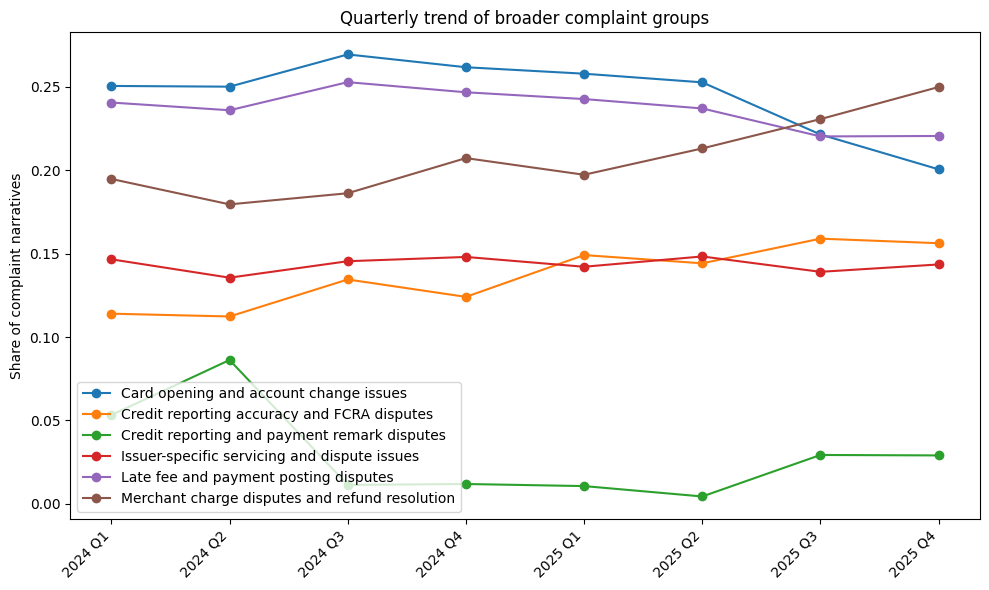

In [23]:
# Plot quarterly theme-share trends for the broader reporting groups.
pivot_trend = quarterly_group_summary.pivot(
    index="quarter_label",
    columns="final_theme_group",
    values="theme_share",
).sort_index()

plt.figure(figsize=(10, 6))

for col in pivot_trend.columns:
    plt.plot(pivot_trend.index, pivot_trend[col], marker="o", label=col)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Share of complaint narratives")
plt.title("Quarterly trend of broader complaint groups")
plt.legend()
plt.tight_layout()
plt.show()

### Compare first and last quarter theme shares

In [25]:
# Compare broader reporting group shares in the first and last quarter.
first_last_quarters = quarterly_group_summary.loc[
    quarterly_group_summary["quarter_label"].isin(["2024 Q1", "2025 Q4"])
].copy()

first_last_compare = (
    first_last_quarters.pivot(
        index="final_theme_group",
        columns="quarter_label",
        values="theme_share",
    )
    .reset_index()
)

first_last_compare["pct_point_change"] = (
    first_last_compare["2025 Q4"] - first_last_compare["2024 Q1"]
)

first_last_compare.sort_values("pct_point_change", ascending=False)

quarter_label,final_theme_group,2024 Q1,2025 Q4,pct_point_change
5,Merchant charge disputes and refund resolution,0.194815,0.249947,0.055132
1,Credit reporting accuracy and FCRA disputes,0.114035,0.156283,0.042248
3,Issuer-specific servicing and dispute issues,0.146635,0.143549,-0.003087
4,Late fee and payment posting disputes,0.240639,0.220585,-0.020054
2,Credit reporting and payment remark disputes,0.053286,0.029047,-0.024240
0,Card opening and account change issues,0.250589,0.200589,-0.050000


### Add directional interpretation to quarter-over-quarter change

In [26]:
# Add a simple directional label to the first-vs-last quarter comparison
first_last_compare["direction"] = first_last_compare["pct_point_change"].apply(
    lambda x: "Increase" if x > 0 else ("Decrease" if x < 0 else "Flat")
)

first_last_compare["pct_point_change"] = first_last_compare["pct_point_change"].round(4)

first_last_compare.sort_values("pct_point_change", ascending=False)

quarter_label,final_theme_group,2024 Q1,2025 Q4,pct_point_change,direction
5,Merchant charge disputes and refund resolution,0.194815,0.249947,0.0551,Increase
1,Credit reporting accuracy and FCRA disputes,0.114035,0.156283,0.0422,Increase
3,Issuer-specific servicing and dispute issues,0.146635,0.143549,-0.0031,Decrease
4,Late fee and payment posting disputes,0.240639,0.220585,-0.0201,Decrease
2,Credit reporting and payment remark disputes,0.053286,0.029047,-0.0242,Decrease
0,Card opening and account change issues,0.250589,0.200589,-0.0500,Decrease


### Save final theme outputs

In [27]:
# Save the final modeling outputs for later analysis, visuals, and write-up.
theme_summary_csv = OUTPUT_TABLES / "theme_summary.csv"
final_theme_summary_csv = OUTPUT_TABLES / "final_theme_summary.csv"
quarterly_group_summary_csv = OUTPUT_TABLES / "quarterly_group_summary.csv"
first_last_compare_csv = OUTPUT_TABLES / "first_last_compare.csv"
model_input_csv = DATA_PROCESSED / "cfpb_credit_card_complaints_modeled.csv"

theme_summary.to_csv(theme_summary_csv, index=False)
final_theme_summary.to_csv(final_theme_summary_csv, index=False)
quarterly_group_summary.to_csv(quarterly_group_summary_csv, index=False)
first_last_compare.to_csv(first_last_compare_csv, index=False)
model_input.to_csv(model_input_csv, index=False)

theme_summary_csv, final_theme_summary_csv, quarterly_group_summary_csv, first_last_compare_csv, model_input_csv

(WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/outputs/tables/theme_summary.csv'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/outputs/tables/final_theme_summary.csv'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/outputs/tables/quarterly_group_summary.csv'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/outputs/tables/first_last_compare.csv'),
 WindowsPath('c:/Users/tivon/postgres-lab/python-cfpb-complaint-nlp/data/processed/cfpb_credit_card_complaints_modeled.csv'))